# 01. Introduction

Project: Gym Customer Churn Prediction.

Notebook này tiếp nối notebook 03_feature_engineering_models.ipynb. Ta sử dụng lại bộ feature engineering tốt nhất, sau đó kiểm tra các kỹ thuật xử lý mất cân bằng dữ liệu có giúp cải thiện khả năng phát hiện khách hàng churn hay không.

Dataset có churn rate khoảng 26-27%, tức imbalance nhẹ/vừa. Baseline + feature engineering đã đạt kết quả cao, nhưng trong churn prediction, mục tiêu quan trọng là phát hiện đúng khách churn.

Metric ưu tiên: Recall class 1, F1 class 1, ROC-AUC và PR-AUC. Accuracy không phải metric chính.

Nguyên tắc: split train-test trước, feature engineering không dùng target, sampling chỉ áp dụng trên train set, tuyệt đối không oversample test set.


# 02. Import Libraries


In [1]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("xgboost is not installed. XGBoost will be skipped.")
try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
    print("lightgbm is not installed. LightGBM will be skipped.")
try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("catboost is not installed. CatBoost will be skipped.")
try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except ImportError:
    RandomOverSampler = SMOTE = BorderlineSMOTE = ADASYN = None
    ImbPipeline = None
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn is not installed. Oversampling strategies will be skipped.")

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET_COL = "Churn"

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# 03. Load Dataset

Load CSV, kiểm tra shape, head, target distribution và vẽ countplot target.


Dataset shape: 4,000 rows x 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.2275,5.0000,3,0.0204,0.0000,0
1,0,1,0,0,1,12,1,31,113.2029,12.0000,7,1.9229,1.9102,0
2,0,1,1,0,1,1,0,28,129.4485,1.0000,2,1.8591,1.7365,0
3,0,1,1,1,1,12,1,33,62.6699,12.0000,2,3.2056,3.3572,0
4,1,1,1,1,1,1,0,26,198.3623,1.0000,3,1.1139,1.1201,0


,count,percentage
Churn,,
0,2939,73.4700
1,1061,26.5200


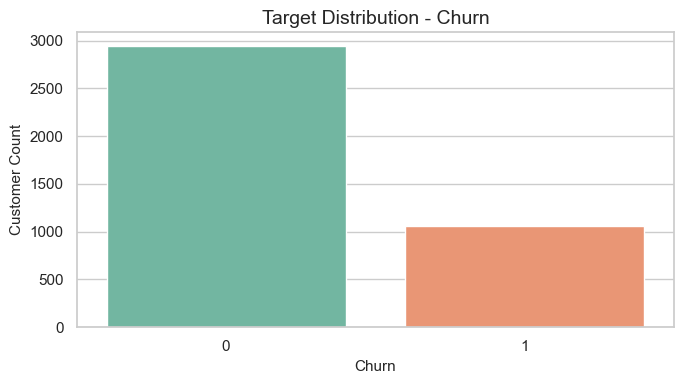

In [2]:
PROJECT_NAME = "Gym Customer Churn Prediction"
DATA_PATH_CANDIDATES = [
    Path(r"D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv"),
    Path.cwd() / "Data" / "gym_churn_us.csv",
    Path.cwd().parent / "Data" / "gym_churn_us.csv",
]
DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), DATA_PATH_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found. Tried: {[str(p) for p in DATA_PATH_CANDIDATES]}")
PROJECT_ROOT = DATA_PATH.parent.parent
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())
if TARGET_COL not in df.columns:
    raise KeyError(f"Target column {TARGET_COL} not found.")
target_distribution = pd.DataFrame({
    "count": df[TARGET_COL].value_counts().sort_index(),
    "percentage": (df[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2),
})
display(target_distribution)
plt.figure(figsize=(7,4))
sns.countplot(data=df, x=TARGET_COL, palette="Set2")
plt.title("Target Distribution - Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "imbalance_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# 04. Define Original Features and Target


In [3]:
ORIGINAL_FEATURES = [
    "gender", "Near_Location", "Partner", "Promo_friends", "Phone",
    "Contract_period", "Group_visits", "Age", "Avg_additional_charges_total",
    "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
]
missing_features = [c for c in ORIGINAL_FEATURES if c not in df.columns]
if missing_features:
    print("Warning: missing features skipped:", missing_features)
original_features = [c for c in ORIGINAL_FEATURES if c in df.columns]
X_original = df[original_features].copy()
y = df[TARGET_COL].copy()
print("Original feature count:", len(original_features))
print("X_original shape:", X_original.shape)
print("y shape:", y.shape)


Original feature count: 13
X_original shape: (4000, 13)
y shape: (4000,)


# 05. Train-Test Split

Dùng stratify để giữ tỷ lệ churn giữa train và test set.


In [4]:
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("X_train shape:", X_train_original.shape)
print("X_test shape:", X_test_original.shape)
print("Train target distribution:")
display(pd.DataFrame({"count": y_train.value_counts().sort_index(), "percentage": (y_train.value_counts(normalize=True).sort_index()*100).round(2)}))
print("Test target distribution:")
display(pd.DataFrame({"count": y_test.value_counts().sort_index(), "percentage": (y_test.value_counts(normalize=True).sort_index()*100).round(2)}))


X_train shape: (3200, 13)
X_test shape: (800, 13)
Train target distribution:


,count,percentage
Churn,,
0,2351,73.4700
1,849,26.5300


Test target distribution:


,count,percentage
Churn,,
0,588,73.5000
1,212,26.5000


# 06. Feature Engineering Function

Copy lại feature engineering từ notebook 03. Function không dùng target, thresholds spending được fit trên train, apply sang test, sau đó replace inf và fill missing bằng 0.


In [5]:
def get_col(data: pd.DataFrame, column: str, default=0):
    if column in data.columns:
        return data[column]
    return pd.Series(default, index=data.index)


def calculate_feature_thresholds(X_train_data: pd.DataFrame) -> dict:
    if "Avg_additional_charges_total" not in X_train_data.columns:
        return {"spending_q25": 0, "spending_q75": 0}
    return {
        "spending_q25": X_train_data["Avg_additional_charges_total"].quantile(0.25),
        "spending_q75": X_train_data["Avg_additional_charges_total"].quantile(0.75),
    }


def create_features(data: pd.DataFrame, thresholds: dict | None = None) -> pd.DataFrame:
    df_fe = data.copy()
    eps = 1e-6
    lifetime = get_col(df_fe, "Lifetime")
    freq_total = get_col(df_fe, "Avg_class_frequency_total")
    freq_current = get_col(df_fe, "Avg_class_frequency_current_month")
    contract_period = get_col(df_fe, "Contract_period")
    month_to_end = get_col(df_fe, "Month_to_end_contract")
    charges = get_col(df_fe, "Avg_additional_charges_total")
    near = get_col(df_fe, "Near_Location")
    partner = get_col(df_fe, "Partner")
    promo = get_col(df_fe, "Promo_friends")
    phone = get_col(df_fe, "Phone")
    group = get_col(df_fe, "Group_visits")

    df_fe["frequency_drop"] = freq_total - freq_current
    df_fe["frequency_ratio_current_total"] = freq_current / (freq_total + eps)
    df_fe["low_current_activity"] = (freq_current < 1).astype(int)
    df_fe["high_current_activity"] = (freq_current >= 3).astype(int)
    df_fe["engagement_score"] = lifetime * freq_current
    df_fe["total_engagement_score"] = lifetime * freq_total

    df_fe["contract_remaining_ratio"] = month_to_end / (contract_period + eps)
    df_fe["is_contract_ending"] = (month_to_end <= 1).astype(int)
    df_fe["is_short_contract"] = (contract_period <= 1).astype(int)
    df_fe["is_long_contract"] = (contract_period >= 12).astype(int)
    df_fe["renewal_pressure_score"] = df_fe["is_contract_ending"] * df_fe["is_short_contract"]

    df_fe["is_new_customer"] = (lifetime <= 1).astype(int)
    df_fe["is_loyal_customer"] = (lifetime >= 6).astype(int)
    df_fe["lifetime_per_contract"] = lifetime / (contract_period + eps)
    df_fe["loyalty_score"] = lifetime * contract_period

    if thresholds is None:
        q25, q75 = charges.quantile(0.25), charges.quantile(0.75)
    else:
        q25, q75 = thresholds.get("spending_q25", 0), thresholds.get("spending_q75", 0)
    df_fe["spending_per_month"] = charges / (lifetime + 1)
    df_fe["high_spending"] = (charges >= q75).astype(int)
    df_fe["low_spending"] = (charges <= q25).astype(int)

    df_fe["convenience_score"] = near + partner + promo + phone
    df_fe["social_commitment_score"] = group + promo + partner
    df_fe["far_no_group"] = ((near == 0) & (group == 0)).astype(int)
    df_fe["no_contact_info"] = (phone == 0).astype(int)

    df_fe["new_low_activity"] = df_fe["is_new_customer"] * df_fe["low_current_activity"]
    df_fe["ending_low_activity"] = df_fe["is_contract_ending"] * df_fe["low_current_activity"]
    df_fe["far_low_activity"] = (1 - near) * df_fe["low_current_activity"]
    df_fe["short_contract_low_activity"] = df_fe["is_short_contract"] * df_fe["low_current_activity"]
    df_fe["no_group_low_activity"] = (1 - group) * df_fe["low_current_activity"]
    df_fe["partner_long_contract"] = partner * df_fe["is_long_contract"]
    df_fe["promo_group"] = promo * group

    df_fe["log_lifetime"] = np.log1p(lifetime.clip(lower=0))
    df_fe["log_additional_charges"] = np.log1p(charges.clip(lower=0))
    df_fe["log_frequency_current"] = np.log1p(freq_current.clip(lower=0))
    df_fe["log_frequency_total"] = np.log1p(freq_total.clip(lower=0))

    return df_fe.replace([np.inf, -np.inf], np.nan).fillna(0)


# 07. Apply Feature Engineering


In [6]:
feature_thresholds = calculate_feature_thresholds(X_train_original)
X_train_fe = create_features(X_train_original, thresholds=feature_thresholds)
X_test_fe = create_features(X_test_original, thresholds=feature_thresholds)
new_features = [c for c in X_train_fe.columns if c not in X_train_original.columns]
print("Original feature count:", X_train_original.shape[1])
print("FE feature count:", X_train_fe.shape[1])
print("New feature count:", len(new_features))
print(new_features)
display(pd.DataFrame({
    "dataset": ["X_train_fe", "X_test_fe"],
    "missing_values": [int(X_train_fe.isna().sum().sum()), int(X_test_fe.isna().sum().sum())],
    "infinite_values": [int(np.isinf(X_train_fe.to_numpy()).sum()), int(np.isinf(X_test_fe.to_numpy()).sum())],
}))


Original feature count: 13
FE feature count: 46
New feature count: 33
['frequency_drop', 'frequency_ratio_current_total', 'low_current_activity', 'high_current_activity', 'engagement_score', 'total_engagement_score', 'contract_remaining_ratio', 'is_contract_ending', 'is_short_contract', 'is_long_contract', 'renewal_pressure_score', 'is_new_customer', 'is_loyal_customer', 'lifetime_per_contract', 'loyalty_score', 'spending_per_month', 'high_spending', 'low_spending', 'convenience_score', 'social_commitment_score', 'far_no_group', 'no_contact_info', 'new_low_activity', 'ending_low_activity', 'far_low_activity', 'short_contract_low_activity', 'no_group_low_activity', 'partner_long_contract', 'promo_group', 'log_lifetime', 'log_additional_charges', 'log_frequency_current', 'log_frequency_total']


,dataset,missing_values,infinite_values
0,X_train_fe,0,0
1,X_test_fe,0,0


# 08. Define Models


In [7]:
def build_base_models():
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    }
    if XGBClassifier is not None:
        models["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    if LGBMClassifier is not None:
        models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    if CatBoostClassifier is not None:
        models["CatBoost"] = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
    return models

base_models = build_base_models()
print(list(base_models.keys()))


['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']


# 09. Define Imbalance Strategies

Class weight models và oversampling strategies. Nếu imbalanced-learn chưa cài, notebook chỉ skip oversampling.


In [8]:
if IMBLEARN_AVAILABLE:
    imbalance_strategies = {
        "No Handling": None,
        "RandomOverSampler": RandomOverSampler(random_state=RANDOM_STATE),
        "SMOTE": SMOTE(random_state=RANDOM_STATE),
        "BorderlineSMOTE": BorderlineSMOTE(random_state=RANDOM_STATE),
        "ADASYN": ADASYN(random_state=RANDOM_STATE),
    }
else:
    imbalance_strategies = {"No Handling": None}

num_negative = int((y_train == 0).sum())
num_positive = int((y_train == 1).sum())
scale_pos_weight = num_negative / num_positive if num_positive else 1

class_weight_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"),
}
if XGBClassifier is not None:
    class_weight_models["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight, verbosity=0)
if LGBMClassifier is not None:
    class_weight_models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced", verbose=-1)
if CatBoostClassifier is not None:
    class_weight_models["CatBoost"] = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE, auto_class_weights="Balanced")

print("Strategies:", list(imbalance_strategies.keys()))
print("Class-weight models:", list(class_weight_models.keys()))
print(f"scale_pos_weight: {scale_pos_weight:.4f}")


Strategies: ['No Handling', 'RandomOverSampler', 'SMOTE', 'BorderlineSMOTE', 'ADASYN']
Class-weight models: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']
scale_pos_weight: 2.7691


# 10. Evaluation Function


In [9]:
def evaluate_predictions(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        "PR_AUC": average_precision_score(y_true, y_proba) if y_proba is not None else np.nan,
    }


def get_positive_scores(pipeline, X_data):
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X_data)[:, 1]
    if hasattr(pipeline, "decision_function"):
        return pipeline.decision_function(X_data)
    return None


def build_standard_pipeline(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])


def build_sampling_pipeline(model, sampler):
    if not IMBLEARN_AVAILABLE:
        raise ImportError("imbalanced-learn is required for sampling pipeline")
    return ImbPipeline([("scaler", StandardScaler()), ("sampler", sampler), ("model", model)])


def fit_evaluate_pipeline(experiment, strategy, model_name, pipeline):
    pipeline.fit(X_train_fe, y_train)
    y_pred = pipeline.predict(X_test_fe)
    y_proba = get_positive_scores(pipeline, X_test_fe)
    return {"Experiment": experiment, "Strategy": strategy, "Model": model_name, **evaluate_predictions(y_test, y_pred, y_proba)}, pipeline


# 11. Train and Evaluate: No Handling


In [10]:
results = []
trained_pipelines = {}
for model_name, model in base_models.items():
    print(f"Training FE Only - {model_name}...")
    try:
        row, fitted = fit_evaluate_pipeline("FE Only", "No Handling", model_name, build_standard_pipeline(clone(model)))
        results.append(row)
        trained_pipelines[("FE Only", "No Handling", model_name)] = fitted
    except Exception as exc:
        print(f"Warning: failed {model_name}: {exc}")
results_no_handling = pd.DataFrame([r for r in results if r["Experiment"] == "FE Only"])
display(results_no_handling.sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False))


Training FE Only - Logistic Regression...
Training FE Only - Random Forest...
Training FE Only - Extra Trees...
Training FE Only - XGBoost...
Training FE Only - LightGBM...
Training FE Only - CatBoost...


,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
1,FE Only,No Handling,Random Forest,0.9650,0.9554,0.9104,0.9324,0.9544,0.9885,0.9764
3,FE Only,No Handling,XGBoost,0.9600,0.9412,0.9057,0.9231,0.9480,0.9886,0.9757
5,FE Only,No Handling,CatBoost,0.9600,0.9455,0.9009,0.9227,0.9479,0.9896,0.9785
4,FE Only,No Handling,LightGBM,0.9587,0.9409,0.9009,0.9205,0.9463,0.9883,0.9754
2,FE Only,No Handling,Extra Trees,0.9487,0.9212,0.8821,0.9012,0.9333,0.9820,0.9549
0,FE Only,No Handling,Logistic Regression,0.9313,0.8867,0.8491,0.8675,0.9105,0.9779,0.9521


# 12. Train and Evaluate: Class Weight


In [11]:
for model_name, model in class_weight_models.items():
    print(f"Training FE + Class Weight - {model_name}...")
    try:
        row, fitted = fit_evaluate_pipeline("FE + Class Weight", "Class Weight", model_name, build_standard_pipeline(clone(model)))
        results.append(row)
        trained_pipelines[("FE + Class Weight", "Class Weight", model_name)] = fitted
    except Exception as exc:
        print(f"Warning: failed class weight {model_name}: {exc}")
results_class_weight = pd.DataFrame([r for r in results if r["Strategy"] == "Class Weight"])
display(results_class_weight.sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False))


Training FE + Class Weight - Logistic Regression...
Training FE + Class Weight - Random Forest...
Training FE + Class Weight - Extra Trees...
Training FE + Class Weight - XGBoost...
Training FE + Class Weight - LightGBM...
Training FE + Class Weight - CatBoost...


,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
1,FE + Class Weight,Class Weight,Random Forest,0.9650,0.9600,0.9057,0.9320,0.9542,0.9885,0.9755
5,FE + Class Weight,Class Weight,CatBoost,0.9563,0.9078,0.9292,0.9184,0.9443,0.9898,0.9791
4,FE + Class Weight,Class Weight,LightGBM,0.9550,0.9231,0.9057,0.9143,0.9419,0.9879,0.9756
3,FE + Class Weight,Class Weight,XGBoost,0.9525,0.9143,0.9057,0.9100,0.9388,0.9875,0.9731
2,FE + Class Weight,Class Weight,Extra Trees,0.9487,0.9254,0.8774,0.9007,0.9331,0.9830,0.9558
0,FE + Class Weight,Class Weight,Logistic Regression,0.9275,0.8319,0.9104,0.8694,0.9096,0.9773,0.9495


# 13. Train and Evaluate: Oversampling Methods

Sampler nằm trong ImbPipeline nên chỉ resample train set. Test set gốc không bị thay đổi.


In [12]:
sampling_strategy_names = ["RandomOverSampler", "SMOTE", "BorderlineSMOTE", "ADASYN"]
if not IMBLEARN_AVAILABLE:
    print("imbalanced-learn is not available. Oversampling experiments are skipped.")
else:
    for strategy_name in sampling_strategy_names:
        sampler = imbalance_strategies[strategy_name]
        for model_name, model in base_models.items():
            print(f"Training FE + {strategy_name} - {model_name}...")
            try:
                row, fitted = fit_evaluate_pipeline(f"FE + {strategy_name}", strategy_name, model_name, build_sampling_pipeline(clone(model), clone(sampler)))
                results.append(row)
                trained_pipelines[(f"FE + {strategy_name}", strategy_name, model_name)] = fitted
            except Exception as exc:
                print(f"Warning: failed {strategy_name} {model_name}: {exc}")
results_sampling = pd.DataFrame([r for r in results if r["Strategy"] in sampling_strategy_names])
if not results_sampling.empty:
    display(results_sampling.sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False))


Training FE + RandomOverSampler - Logistic Regression...
Training FE + RandomOverSampler - Random Forest...
Training FE + RandomOverSampler - Extra Trees...
Training FE + RandomOverSampler - XGBoost...
Training FE + RandomOverSampler - LightGBM...
Training FE + RandomOverSampler - CatBoost...
Training FE + SMOTE - Logistic Regression...
Training FE + SMOTE - Random Forest...
Training FE + SMOTE - Extra Trees...
Training FE + SMOTE - XGBoost...
Training FE + SMOTE - LightGBM...
Training FE + SMOTE - CatBoost...
Training FE + BorderlineSMOTE - Logistic Regression...
Training FE + BorderlineSMOTE - Random Forest...
Training FE + BorderlineSMOTE - Extra Trees...
Training FE + BorderlineSMOTE - XGBoost...
Training FE + BorderlineSMOTE - LightGBM...
Training FE + BorderlineSMOTE - CatBoost...
Training FE + ADASYN - Logistic Regression...
Training FE + ADASYN - Random Forest...
Training FE + ADASYN - Extra Trees...
Training FE + ADASYN - XGBoost...
Training FE + ADASYN - LightGBM...
Training 

,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
3,FE + RandomOverSampler,RandomOverSampler,XGBoost,0.9613,0.9289,0.9245,0.9267,0.9502,0.9856,0.9719
1,FE + RandomOverSampler,RandomOverSampler,Random Forest,0.9613,0.9372,0.9151,0.9260,0.9499,0.9879,0.9738
4,FE + RandomOverSampler,RandomOverSampler,LightGBM,0.9587,0.9324,0.9104,0.9212,0.9466,0.9896,0.9780
15,FE + BorderlineSMOTE,BorderlineSMOTE,XGBoost,0.9575,0.9198,0.9198,0.9198,0.9454,0.9876,0.9738
21,FE + ADASYN,ADASYN,XGBoost,0.9575,0.9198,0.9198,0.9198,0.9454,0.9862,0.9713
5,FE + RandomOverSampler,RandomOverSampler,CatBoost,0.9563,0.9194,0.9151,0.9173,0.9438,0.9904,0.9796
9,FE + SMOTE,SMOTE,XGBoost,0.9563,0.9194,0.9151,0.9173,0.9438,0.9868,0.9732
10,FE + SMOTE,SMOTE,LightGBM,0.9563,0.9234,0.9104,0.9169,0.9436,0.9885,0.9754
7,FE + SMOTE,SMOTE,Random Forest,0.9550,0.9074,0.9245,0.9159,0.9426,0.9871,0.9703
11,FE + SMOTE,SMOTE,CatBoost,0.9550,0.9231,0.9057,0.9143,0.9419,0.9888,0.9775


# 14. Results Comparison


In [13]:
results_df = pd.DataFrame(results).sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False).reset_index(drop=True)
display(results_df.head(20).style.highlight_max(subset=["Precision_1", "Recall_1", "F1_1", "Macro_F1", "ROC_AUC", "PR_AUC"], color="#C8E6C9").format({
    "Accuracy": "{:.4f}", "Precision_1": "{:.4f}", "Recall_1": "{:.4f}", "F1_1": "{:.4f}", "Macro_F1": "{:.4f}", "ROC_AUC": "{:.4f}", "PR_AUC": "{:.4f}"
}))
best_by_strategy = (results_df.sort_values(["Strategy", "F1_1", "Recall_1", "ROC_AUC"], ascending=[True, False, False, False])
                    .groupby("Strategy", as_index=False).head(1)
                    .rename(columns={"Model": "Best_Model"})
                    [["Strategy", "Best_Model", "Accuracy", "Precision_1", "Recall_1", "F1_1", "Macro_F1", "ROC_AUC", "PR_AUC"]]
                    .sort_values("F1_1", ascending=False))
display(best_by_strategy)


,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
0,FE Only,No Handling,Random Forest,0.9650,0.9554,0.9104,0.9324,0.9544,0.9885,0.9764
1,FE + Class Weight,Class Weight,Random Forest,0.9650,0.9600,0.9057,0.9320,0.9542,0.9885,0.9755
2,FE + RandomOverSampler,RandomOverSampler,XGBoost,0.9613,0.9289,0.9245,0.9267,0.9502,0.9856,0.9719
3,FE + RandomOverSampler,RandomOverSampler,Random Forest,0.9613,0.9372,0.9151,0.9260,0.9499,0.9879,0.9738
4,FE Only,No Handling,XGBoost,0.9600,0.9412,0.9057,0.9231,0.9480,0.9886,0.9757
5,FE Only,No Handling,CatBoost,0.9600,0.9455,0.9009,0.9227,0.9479,0.9896,0.9785
6,FE + RandomOverSampler,RandomOverSampler,LightGBM,0.9587,0.9324,0.9104,0.9212,0.9466,0.9896,0.9780
7,FE Only,No Handling,LightGBM,0.9587,0.9409,0.9009,0.9205,0.9463,0.9883,0.9754
8,FE + BorderlineSMOTE,BorderlineSMOTE,XGBoost,0.9575,0.9198,0.9198,0.9198,0.9454,0.9876,0.9738
9,FE + ADASYN,ADASYN,XGBoost,0.9575,0.9198,0.9198,0.9198,0.9454,0.9862,0.9713


,Strategy,Best_Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
0,No Handling,Random Forest,0.9650,0.9554,0.9104,0.9324,0.9544,0.9885,0.9764
1,Class Weight,Random Forest,0.9650,0.9600,0.9057,0.9320,0.9542,0.9885,0.9755
2,RandomOverSampler,XGBoost,0.9613,0.9289,0.9245,0.9267,0.9502,0.9856,0.9719
9,ADASYN,XGBoost,0.9575,0.9198,0.9198,0.9198,0.9454,0.9862,0.9713
8,BorderlineSMOTE,XGBoost,0.9575,0.9198,0.9198,0.9198,0.9454,0.9876,0.9738
12,SMOTE,XGBoost,0.9563,0.9194,0.9151,0.9173,0.9438,0.9868,0.9732


# 15. Visualization

Biểu đồ thể hiện trade-off precision và recall. Tăng recall thường có thể làm precision giảm.


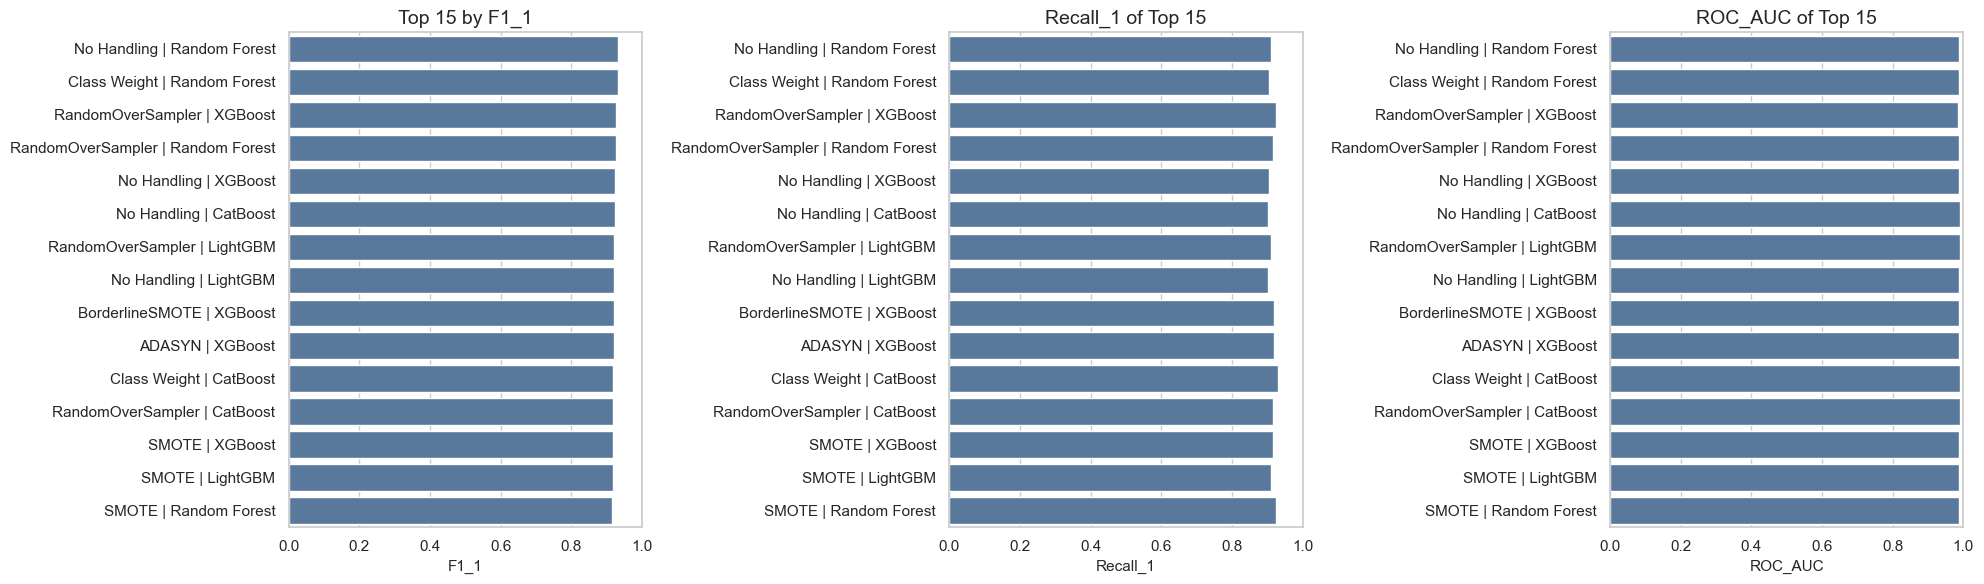

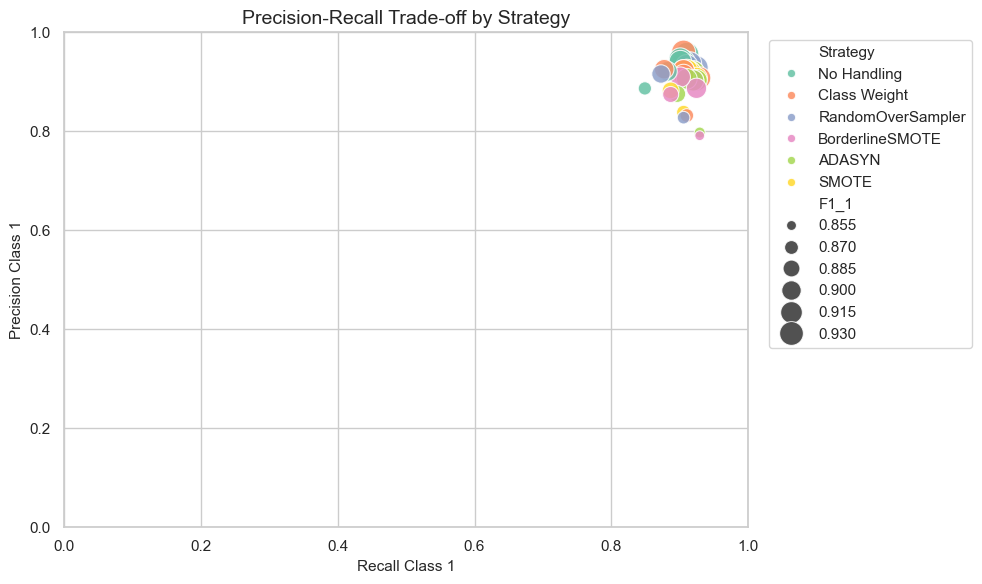

In [14]:
top15 = results_df.head(15).copy()
top15["Label"] = top15["Strategy"] + " | " + top15["Model"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, metric, title in zip(axes, ["F1_1", "Recall_1", "ROC_AUC"], ["Top 15 by F1_1", "Recall_1 of Top 15", "ROC_AUC of Top 15"]):
    sns.barplot(data=top15, y="Label", x=metric, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "imbalance_top15_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="Recall_1", y="Precision_1", hue="Strategy", size="F1_1", sizes=(50, 300), alpha=0.85)
plt.title("Precision-Recall Trade-off by Strategy")
plt.xlabel("Recall Class 1")
plt.ylabel("Precision Class 1")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "imbalance_precision_recall_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()


# 16. Compare Against Notebook 03 Best Result

Reference notebook 03: CatBoost FE ROC_AUC = 0.9897, F1 = 0.9294, Recall = 0.9009, Accuracy = 0.9637.


In [15]:
notebook03_reference = {"Accuracy": 0.9637, "Recall_1": 0.9009, "F1_1": 0.9294, "ROC_AUC": 0.9897}
fe_only_best = results_df[results_df["Experiment"] == "FE Only"].sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False).iloc[0]
best_imbalance = results_df[results_df["Experiment"] != "FE Only"].sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False).iloc[0] if (results_df["Experiment"] != "FE Only").any() else fe_only_best
reference_comparison = pd.DataFrame([
    {"Metric": m, "Notebook03_Reference": notebook03_reference.get(m, np.nan), "FE Only Best": fe_only_best[m], "Best Imbalance Handling": best_imbalance[m], "Delta": best_imbalance[m] - fe_only_best[m]}
    for m in ["Accuracy", "Recall_1", "F1_1", "ROC_AUC"]
])
display(reference_comparison)
print("FE Only best:")
display(fe_only_best.to_frame().T)
print("Best imbalance handling:")
display(best_imbalance.to_frame().T)


,Metric,Notebook03_Reference,FE Only Best,Best Imbalance Handling,Delta
0,Accuracy,0.9637,0.9650,0.9650,0.0000
1,Recall_1,0.9009,0.9104,0.9057,-0.0047
2,F1_1,0.9294,0.9324,0.9320,-0.0003
3,ROC_AUC,0.9897,0.9885,0.9885,0.0000


FE Only best:


,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
0,FE Only,No Handling,Random Forest,0.9650,0.9554,0.9104,0.9324,0.9544,0.9885,0.9764


Best imbalance handling:


,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC
1,FE + Class Weight,Class Weight,Random Forest,0.9650,0.9600,0.9057,0.9320,0.9542,0.9885,0.9755


# 17. Confusion Matrix Analysis

So sánh false negative và false positive cho FE Only best, best imbalance theo F1, và best imbalance theo Recall.


Best FE Only: FE Only | No Handling | Random Forest


,precision,recall,f1-score,support
0,0.9682,0.9847,0.9764,588.0000
1,0.9554,0.9104,0.9324,212.0000
accuracy,0.9650,0.9650,0.9650,0.9650
macro avg,0.9618,0.9475,0.9544,800.0000
weighted avg,0.9648,0.9650,0.9647,800.0000


False Positives: 9
False Negatives: 19


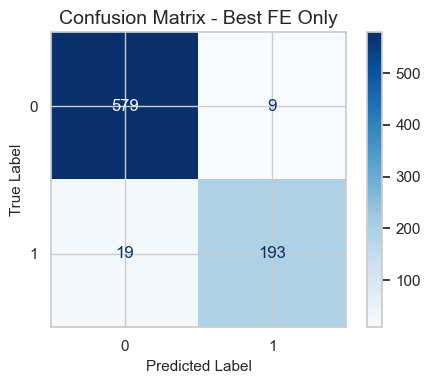

Best Imbalance by F1: FE + Class Weight | Class Weight | Random Forest


,precision,recall,f1-score,support
0,0.9667,0.9864,0.9764,588.0000
1,0.9600,0.9057,0.9320,212.0000
accuracy,0.9650,0.9650,0.9650,0.9650
macro avg,0.9633,0.9460,0.9542,800.0000
weighted avg,0.9649,0.9650,0.9647,800.0000


False Positives: 8
False Negatives: 20


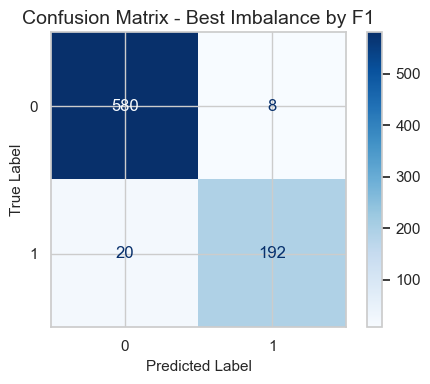

Best Imbalance by Recall: FE + Class Weight | Class Weight | CatBoost


,precision,recall,f1-score,support
0,0.9743,0.9660,0.9701,588.0000
1,0.9078,0.9292,0.9184,212.0000
accuracy,0.9563,0.9563,0.9563,0.9563
macro avg,0.9411,0.9476,0.9443,800.0000
weighted avg,0.9567,0.9563,0.9564,800.0000


False Positives: 20
False Negatives: 15


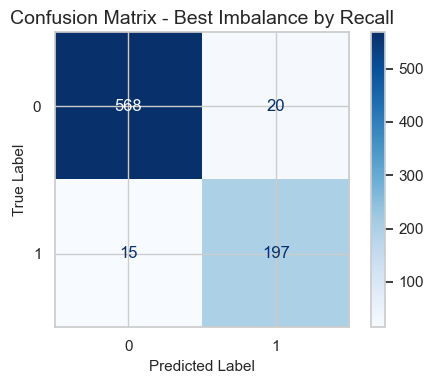

In [16]:
def get_pipeline_from_row(row):
    return trained_pipelines[(row["Experiment"], row["Strategy"], row["Model"])]

candidate_rows = [("Best FE Only", fe_only_best)]
if (results_df["Experiment"] != "FE Only").any():
    best_recall_imbalance = results_df[results_df["Experiment"] != "FE Only"].sort_values(["Recall_1", "F1_1", "ROC_AUC"], ascending=False).iloc[0]
    candidate_rows += [("Best Imbalance by F1", best_imbalance), ("Best Imbalance by Recall", best_recall_imbalance)]
else:
    best_recall_imbalance = fe_only_best

seen = set()
for label, row in candidate_rows:
    key = (row["Experiment"], row["Strategy"], row["Model"])
    if key in seen:
        continue
    seen.add(key)
    pipeline = get_pipeline_from_row(row)
    y_pred = pipeline.predict(X_test_fe)
    print("=" * 80)
    print(f"{label}: {row['Experiment']} | {row['Strategy']} | {row['Model']}")
    display(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T)
    cm = confusion_matrix(y_test, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        print(f"False Positives: {fp}")
        print(f"False Negatives: {fn}")
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix - {label}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"imbalance_confusion_matrix_{label.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


# 18. ROC and PR Curves


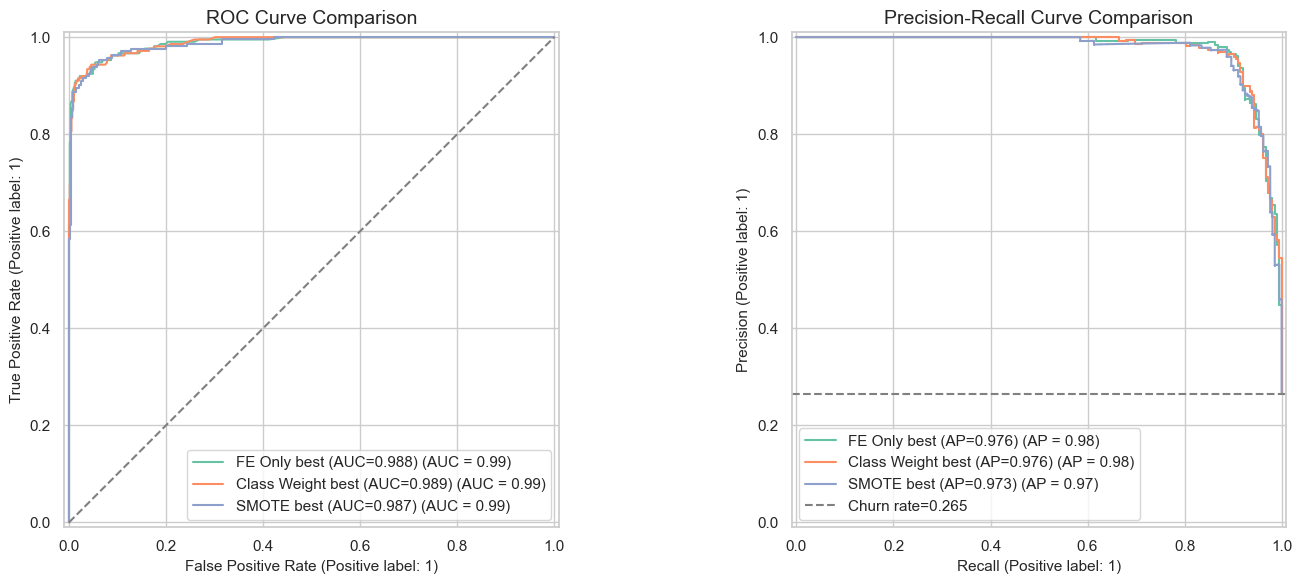

In [17]:
curve_candidates = [("FE Only best", fe_only_best)]
if "Class Weight" in results_df["Strategy"].values:
    class_weight_best = results_df[results_df["Strategy"] == "Class Weight"].sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False).iloc[0]
    curve_candidates.append(("Class Weight best", class_weight_best))
if "SMOTE" in results_df["Strategy"].values:
    smote_best = results_df[results_df["Strategy"] == "SMOTE"].sort_values(["F1_1", "Recall_1", "ROC_AUC"], ascending=False).iloc[0]
    curve_candidates.append(("SMOTE best", smote_best))
curve_candidates.append(("Best overall imbalance", best_imbalance))

unique_curve_candidates, seen = [], set()
for label, row in curve_candidates:
    key = (row["Experiment"], row["Strategy"], row["Model"])
    if key not in seen:
        seen.add(key)
        unique_curve_candidates.append((label, row))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for label, row in unique_curve_candidates:
    pipeline = get_pipeline_from_row(row)
    y_score = get_positive_scores(pipeline, X_test_fe)
    if y_score is None:
        continue
    RocCurveDisplay.from_predictions(y_test, y_score, name=f"{label} (AUC={roc_auc_score(y_test, y_score):.3f})", ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=f"{label} (AP={average_precision_score(y_test, y_score):.3f})", ax=axes[1])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve Comparison")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Churn rate={y_test.mean():.3f}")
axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].legend(loc="best")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "imbalance_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


# 19. Cross Validation for Best Candidates

Với sampler, ImbPipeline đảm bảo sampler chỉ chạy trong training fold. Không oversample trước cross-validation.


Cross-validating FE Only best: No Handling | Random Forest...
Cross-validating Class Weight best: Class Weight | Random Forest...
Cross-validating SMOTE best: SMOTE | XGBoost...


,Candidate,Strategy,Model,mean_recall,std_recall,mean_f1,std_f1,mean_roc_auc,std_roc_auc,mean_pr_auc,std_pr_auc
2,SMOTE best,SMOTE,XGBoost,0.9046,0.0130,0.9035,0.0052,0.9868,0.0009,0.9704,0.0021
0,FE Only best,No Handling,Random Forest,0.8681,0.0261,0.8981,0.0111,0.9850,0.0024,0.9670,0.0056
1,Class Weight best,Class Weight,Random Forest,0.8587,0.0323,0.8931,0.0141,0.9855,0.0017,0.9672,0.0048


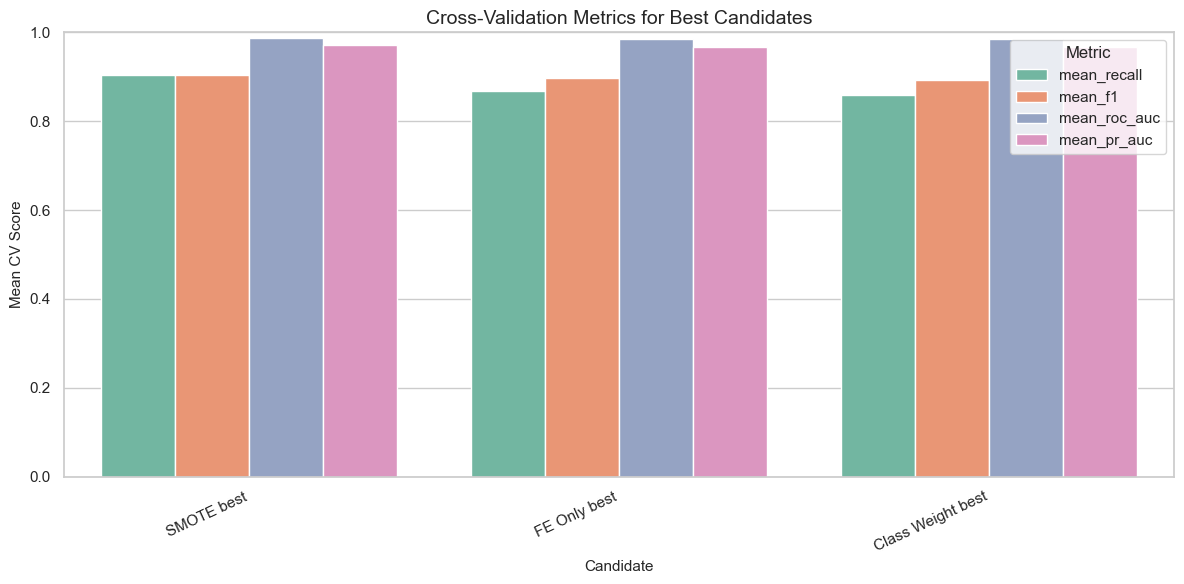

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {"recall": "recall", "f1": "f1", "roc_auc": "roc_auc", "average_precision": "average_precision"}

def make_candidate_pipeline(strategy, model_name, model):
    if strategy in ["RandomOverSampler", "SMOTE", "BorderlineSMOTE", "ADASYN"]:
        return build_sampling_pipeline(clone(model), clone(imbalance_strategies[strategy]))
    return build_standard_pipeline(clone(model))

def cv_for_candidate(label, strategy, model_name, model):
    pipeline = make_candidate_pipeline(strategy, model_name, model)
    scores = cross_validate(pipeline, X_train_fe, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1, error_score=np.nan)
    return {
        "Candidate": label, "Strategy": strategy, "Model": model_name,
        "mean_recall": np.nanmean(scores["test_recall"]), "std_recall": np.nanstd(scores["test_recall"]),
        "mean_f1": np.nanmean(scores["test_f1"]), "std_f1": np.nanstd(scores["test_f1"]),
        "mean_roc_auc": np.nanmean(scores["test_roc_auc"]), "std_roc_auc": np.nanstd(scores["test_roc_auc"]),
        "mean_pr_auc": np.nanmean(scores["test_average_precision"]), "std_pr_auc": np.nanstd(scores["test_average_precision"]),
    }

cv_specs = []
for label, row in unique_curve_candidates:
    strategy, model_name = row["Strategy"], row["Model"]
    source = class_weight_models if strategy == "Class Weight" else base_models
    if model_name in source and (strategy, model_name) not in [(s, m) for _, s, m, _ in cv_specs]:
        cv_specs.append((label, strategy, model_name, source[model_name]))

cv_rows = []
for label, strategy, model_name, model in cv_specs:
    print(f"Cross-validating {label}: {strategy} | {model_name}...")
    try:
        cv_rows.append(cv_for_candidate(label, strategy, model_name, model))
    except Exception as exc:
        print(f"Warning: CV failed for {label}: {exc}")
cv_results_df = pd.DataFrame(cv_rows).sort_values(["mean_f1", "mean_recall", "mean_roc_auc"], ascending=False)
display(cv_results_df)
if not cv_results_df.empty:
    cv_long = cv_results_df.melt(id_vars=["Candidate", "Strategy", "Model"], value_vars=["mean_recall", "mean_f1", "mean_roc_auc", "mean_pr_auc"], var_name="Metric", value_name="Score")
    plt.figure(figsize=(12, 6))
    sns.barplot(data=cv_long, x="Candidate", y="Score", hue="Metric", palette="Set2")
    plt.title("Cross-Validation Metrics for Best Candidates")
    plt.xlabel("Candidate")
    plt.ylabel("Mean CV Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "imbalance_cv_best_candidates.png", dpi=150, bbox_inches="tight")
    plt.show()


# 20. Final Model Selection

Chọn final model theo weighted score ưu tiên F1_1, Recall_1, ROC_AUC và PR_AUC. Đây là rule minh bạch cho baseline, chưa phải tối ưu business threshold.


In [19]:
final_candidates = results_df.copy()
final_candidates["selection_score"] = 0.40*final_candidates["F1_1"] + 0.30*final_candidates["Recall_1"] + 0.20*final_candidates["ROC_AUC"] + 0.10*final_candidates["PR_AUC"]
final_selected = final_candidates.sort_values(["selection_score", "F1_1", "Recall_1"], ascending=False).iloc[0]
final_key = (final_selected["Experiment"], final_selected["Strategy"], final_selected["Model"])
final_pipeline = trained_pipelines[final_key]
print("Final selected strategy:", final_selected["Strategy"])
print("Final selected model:", final_selected["Model"])
print("Final selected experiment:", final_selected["Experiment"])
print("Reason: weighted score prioritizes F1_1, Recall_1, ROC_AUC and PR_AUC.")
display(final_selected.to_frame().T)


Final selected strategy: RandomOverSampler
Final selected model: XGBoost
Final selected experiment: FE + RandomOverSampler
Reason: weighted score prioritizes F1_1, Recall_1, ROC_AUC and PR_AUC.


,Experiment,Strategy,Model,Accuracy,Precision_1,Recall_1,F1_1,Macro_F1,ROC_AUC,PR_AUC,selection_score
2,FE + RandomOverSampler,RandomOverSampler,XGBoost,0.9613,0.9289,0.9245,0.9267,0.9502,0.9856,0.9719,0.9424


# 21. Save Results and Model


In [20]:
results_path = REPORTS_DIR / "imbalance_handling_results.csv"
best_by_strategy_path = REPORTS_DIR / "imbalance_best_by_strategy.csv"
best_model_path = MODELS_DIR / "best_imbalance_model.pkl"
results_df.to_csv(results_path, index=False)
best_by_strategy.to_csv(best_by_strategy_path, index=False)
final_model_artifact = {
    "pipeline": final_pipeline,
    "experiment": final_selected["Experiment"],
    "strategy": final_selected["Strategy"],
    "model_name": final_selected["Model"],
    "feature_thresholds": feature_thresholds,
    "original_features": original_features,
    "feature_engineered_columns": X_train_fe.columns.tolist(),
    "metrics": final_selected.to_dict(),
    "note": "Apply create_features(X, feature_thresholds) before pipeline.predict. Do not oversample test data.",
}
joblib.dump(final_model_artifact, best_model_path)
print(f"Saved results to: {results_path}")
print(f"Saved best-by-strategy table to: {best_by_strategy_path}")
print(f"Saved final model artifact to: {best_model_path}")


Saved results to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\imbalance_handling_results.csv
Saved best-by-strategy table to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\imbalance_best_by_strategy.csv
Saved final model artifact to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\models\best_imbalance_model.pkl


# 22. Final Conclusions

Notebook này kiểm tra imbalance handling sau feature engineering.

Cần kết luận sau khi chạy notebook:

- Imbalance handling có cải thiện Recall_1 và F1_1 không.
- Strategy nào tốt nhất: Class Weight, RandomOverSampler, SMOTE, BorderlineSMOTE hay ADASYN.
- False Negative có giảm không và False Positive tăng bao nhiêu.
- Precision có bị đánh đổi quá mạnh không.
- Nên giữ FE Only model hay chuyển sang imbalance model.

Với churn prediction, bỏ sót khách churn thường tốn kém hơn cảnh báo nhầm. Tuy nhiên false positive quá nhiều cũng làm retention campaign tốn chi phí. Vì vậy cần cân bằng Recall và Precision.

Hướng tiếp theo: hyperparameter tuning, threshold tuning, SHAP explainability và calibration.
